# RNN İle Hava Yolu Yolcu Sayısı Tahmini

## 1- İş Problemi

- Elimizdeki geçmiş verileri kullanarak gelecekte ne kadar yolcunun hava yolu taşımacılığı kullanacağını tahmin edeceğiz.

- Airline Passenger isimli veri setimiz 1949 yılından 1960 yılına kadar olacak şekilde aylık olarak yolcu sayılarını ifade etmektedir.

    - Month: Aylık olarak yer alan tarih değişkenidir
    - Passengers: İlgili işlem tarihindeki yolcu sayısını yani aylık yolcu sayısını temsil etmektedir.

## 2- Veriyi Anlamak

### 2.1 Gerekli Kütüphaneleri Import İşlemleri

In [3]:
# Veriyi okuma ve işleme adımında kullanılacak kütüphaneler
import numpy as np
import pandas as pd
import datetime as dt
import tensorflow as tf
import matplotlib.pyplot as plt

# Model değerlendirme ve veriyi scale etme için gerekli kütüphaneler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Model için kullanılacak olan kütüphaneler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Warnginleri kapatma
import warnings
warnings.filterwarnings("ignore")

 # Tensorflow Warninglerini kapatma
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

### 2.2 Veri Setinin Yüklenmesi ve Verinin Genel Resminin İncelenmesi

In [6]:
df = pd.read_csv("international-airline-passengers.csv")

In [7]:
df.head()

,Month,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [8]:
df.columns

Index(['Month', 'International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60'], dtype='object')

In [15]:
df.columns = ["Month", "Passengers"]

In [16]:
df.head()

,Month,Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [17]:
df.tail()

,Month,Passengers
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


In [18]:
df.shape

(145, 2)

In [ ]:
df.dtypes

# Son sütunu df'ten çıkarmalıyız ve Month sütununu datetime formatına çevirmeliyiz

Month          object
Passengers    float64
dtype: object

In [20]:
df.isnull().sum()

Month         0
Passengers    1
dtype: int64

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Passengers,144.0,280.298611,119.966317,104.0,180.0,265.5,360.5,622.0


## 3- Veriyi Hazırlamak

In [ ]:
# Son satırdaki bozuk veriden kurtulalım
df = df[:144]

In [25]:
df.tail()

,Month,Passengers
139,1960-08,606.0
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0


In [26]:
# Month sütununu datetime formatına çevirelim
df["Month"] = pd.to_datetime(df["Month"])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.4 KB


In [34]:
print(f"Maksimum Tarih: {df["Month"].max()}")
print(f"Minimum Tarih: {df["Month"].min()}")

Maksimum Tarih: 1960-12-01 00:00:00
Minimum Tarih: 1949-01-01 00:00:00


In [35]:
df.index = df["Month"]

In [36]:
df.head()

,Month,Passengers
Month,,
1949-01-01,1949-01-01,112.0
1949-02-01,1949-02-01,118.0
1949-03-01,1949-03-01,132.0
1949-04-01,1949-04-01,129.0
1949-05-01,1949-05-01,121.0


In [37]:
df.drop("Month", axis=1, inplace=True)

In [38]:
df.head()

,Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


In [39]:
result_df = df.copy()

<Axes: title={'center': 'Aylık Hava Yolu Yolcu Sayısı'}, xlabel='Month'>

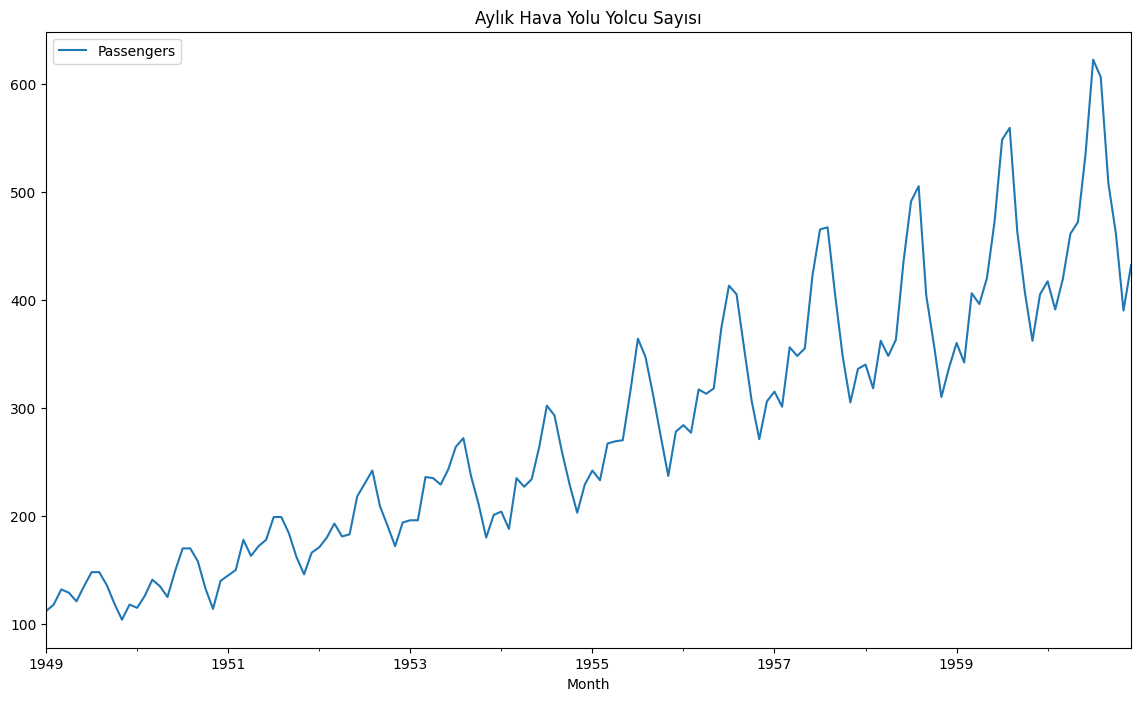

In [43]:
df.plot(figsize=(14,8), title="Aylık Hava Yolu Yolcu Sayısı")

In [45]:
data = df["Passengers"].values
data[0:5]

array([112., 118., 132., 129., 121.])

In [ ]:
type(data)

# Numpy array'e çevirmemizdeki sebep:  modele bu tip veriyi vermiş olduk

numpy.ndarray

In [47]:
type(data[0])

numpy.float64

In [48]:
data = data.astype("float32")

In [49]:
type(data[0])

numpy.float32

In [50]:
data.shape

(144,)

In [53]:
data = data.reshape(-1,1)
data.shape

(144, 1)

In [54]:
# Zaman serisi problemiyle ilgilendiğimiz için "train_test_split" fonksiyonu yerine basit bir fonksiyon tanımlıyoruz... 
# ...Çünkü zaman serisi verilerinde veriyi rastgele bölmek yerine, zaman sırasına göre bölmemiz gerekir.

def split_data(dataframe, test_size):
    position = int(round(len(dataframe) * (1-test_size)))
    train = dataframe[:position]
    test = dataframe[position:]
    return train , test , position

In [57]:
train, test, positon = split_data(data, 0.33)

In [59]:
print("Train Shape: ", train.shape)
print("Test Shape: ", test.shape)

Train Shape:  (96, 1)
Test Shape:  (48, 1)


In [63]:
# MinMaxScaler ile veriyi normalize edelim
scaler = MinMaxScaler(feature_range=(0, 1))
scaler_train = scaler.fit_transform(train)
scaler_test = scaler.transform(test)

In [64]:
train[0:5]

array([[0.02588999],
       [0.04530746],
       [0.09061491],
       [0.08090615],
       [0.05501619]], dtype=float32)

In [65]:
test[0:5]

array([[0.682848  ],
       [0.63754046],
       [0.815534  ],
       [0.7896441 ],
       [0.8122978 ]], dtype=float32)

In [ ]:
# Zaman serilerinde zamanın t anındaki değeri en fazla kendisiden bir önceki zaman periyodundan etkileniyor...
#... Bu yüzden bir feature tanımlama fonksiyonu tanımlıyoruz ve bir periyot öncesindeki değeri modele featrure olarak vereceğiz
#... Yani pazartesi günü için modelimize pazar gününün değerini feature olarak vereceğiz. Ya da bir haftanın verisini bulmak için bir önceki haftranın verisini kullanacağız.

def create_features(data, lookback = 1):
    X, Y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i , 0])
        Y.append(data[i,0])
    
    return np.array(X), np.array(Y)

In [ ]:
# Train veri seti

X_train , y_train = create_features(train, lookback=1)

In [68]:
# Test veri seti
X_test , y_test = create_features(test, lookback=1)

In [72]:
print(X_train.shape , y_train.shape, X_test.shape, y_test.shape)

(95, 1) (95,) (47, 1) (47,)


In [75]:
# Sinir ağına göndermeden önce veriyi 3 boyutlu hale getirmeliyiz. Çünkü RNN katmanları 3 boyutlu verilerle çalışır.

X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
y_train = y_train.reshape(-1, 1)

X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))
y_test = y_test.reshape(-1, 1)

In [76]:
print(X_train.shape , y_train.shape, X_test.shape, y_test.shape)

(95, 1, 1) (95, 1) (47, 1, 1) (47, 1)


## Modelleme

In [81]:
lookback = 1

model = Sequential()
model.add(SimpleRNN(units=50, activation="relu", input_shape=(X_train.shape[1], lookback)))
model.add(Dropout(0.2))
model.add(Dense(1))


In [82]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
model.compile(optimizer="adam", loss="mean_squared_error")

In [94]:
callbacks = [EarlyStopping(monitor="val_loss", patience=3, verbose=1, mode="min"),
             ModelCheckpoint(filepath="mymodel.weights.h5", monitor="val_loss", mode="min", save_best_only=True, save_weights_only=True, verbose=1)]

In [97]:
history = model.fit(X_train, y_train, epochs=50, batch_size=1, validation_data=(X_test, y_test), callbacks=callbacks,shuffle=False)

Epoch 1/50
37/95 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0030 
Epoch 1: val_loss improved from 0.02320 to 0.02303, saving model to mymodel.weights.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0039 - val_loss: 0.0230
Epoch 2/50
61/95 ━━━━━━━━━━━━━━━━━━━━ 0s 835us/step - loss: 0.0039
Epoch 2: val_loss improved from 0.02303 to 0.02264, saving model to mymodel.weights.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0048 - val_loss: 0.0226
Epoch 3/50
63/95 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step - loss: 0.0032
Epoch 3: val_loss did not improve from 0.02264
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0043 - val_loss: 0.0247
Epoch 4/50
57/95 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - loss: 0.0029
Epoch 4: val_loss improved from 0.02264 to 0.02259, saving model to mymodel.weights.h5
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0046 - val_loss: 0.0226
Epoch 5/50
49/95 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039 
Epoch 5: val_loss did not improve from 0.02259
95/95 ━━━━━━━━━━━━━━

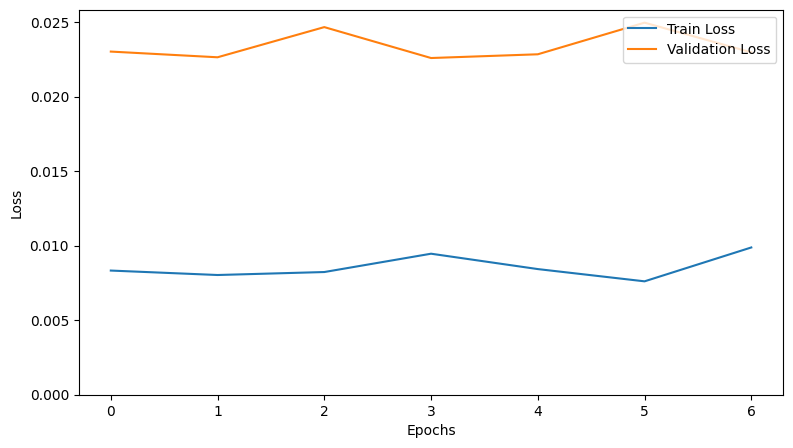

In [99]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend(loc="upper right")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.ylim(0, max(plt.ylim()))
plt.show()

## Değerlendirme

In [104]:
loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss}")

Test Loss: 0.022974897176027298


In [105]:
train_predict = model.predict(X_train)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
